## Environment Setup & Data Loadin

In [4]:
# Force-install required production settings packages into the active notebook kernel
%pip install pydantic-settings pymysql cryptography

  Using cached cryptography-48.0.0-cp311-abi3-win_amd64.whl.metadata (4.3 kB)
Using cached cryptography-48.0.0-cp311-abi3-win_amd64.whl (3.8 MB)

   ------------- -------------------------- 1/3 [cryptography]
   ------------- -------------------------- 1/3 [cryptography]
   ---------------------------------------- 3/3 [pydantic-settings]

Note: you may need to restart the kernel to use updated packages.


In [5]:
import os
import sys
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Aligning project root to import our custom data loaders
sys.path.append(os.path.abspath(os.path.join("..")))
from app.services.data_loader import load_harvest_full

# Set globally approved plotting styles
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = [10, 6]

# Load the primary unified view dataset
df = load_harvest_full()
print(f"Dataset successfully loaded with shape: {df.shape}")

Dataset successfully loaded with shape: (150, 32)


## Dataset Meta-Information & Schema Check

In [6]:
print("--- Dataset Structural Info ---")
print(df.info())

print("\n--- Missing Value Count Per Column ---")
print(df.isnull().sum())

--- Dataset Structural Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   harvest_id              150 non-null    int64  
 1   farm_name               150 non-null    object 
 2   owner_name              150 non-null    object 
 3   region                  150 non-null    object 
 4   farm_district           150 non-null    object 
 5   farm_type               150 non-null    object 
 6   total_area_ha           150 non-null    float64
 7   crop_name               150 non-null    object 
 8   crop_category           150 non-null    object 
 9   growing_season          150 non-null    object 
 10  full_date               150 non-null    object 
 11  month_name              150 non-null    object 
 12  quarter                 150 non-null    int64  
 13  year                    150 non-null    int64  
 14  season    

## Distribution of Categorical Fields

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_32960\1324352930.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="crop_category", ax=axes[0], palette="viridis")
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_32960\1324352930.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="market_type", ax=axes[1], palette="magma")


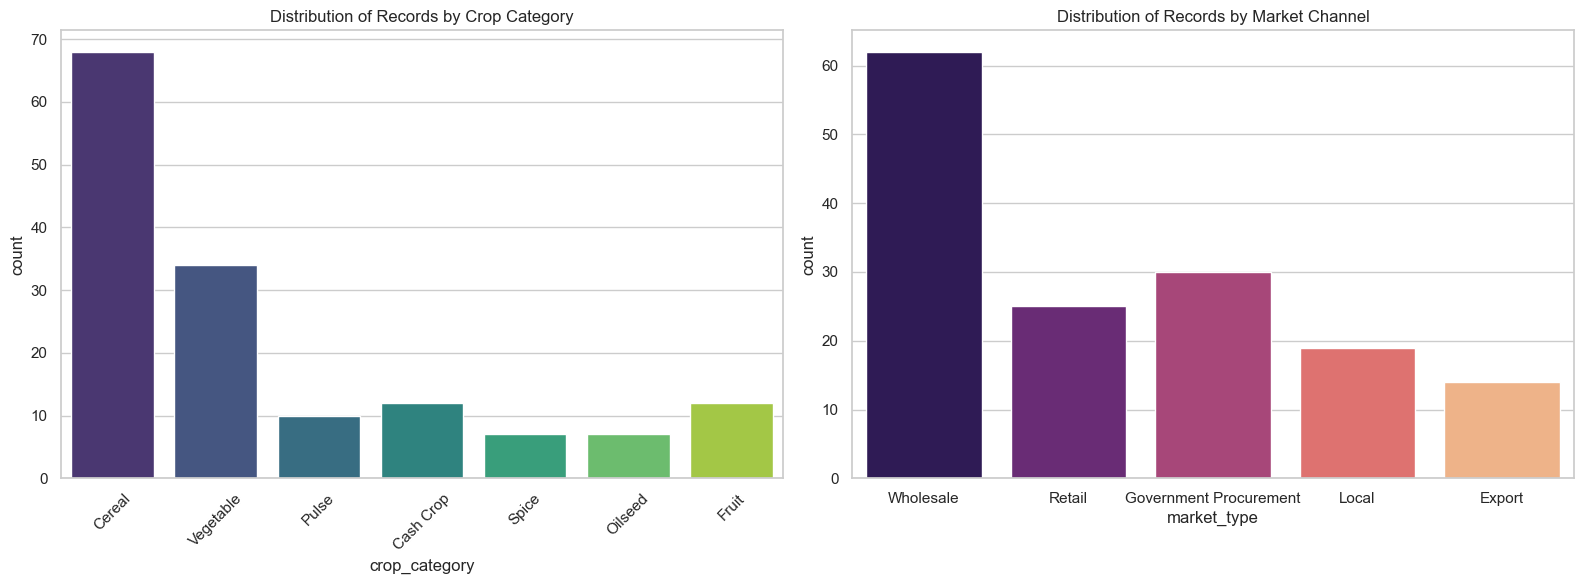

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Crop Category Countplot
sns.countplot(data=df, x="crop_category", ax=axes[0], palette="viridis")
axes[0].set_title("Distribution of Records by Crop Category")
axes[0].tick_params(axis="x", rotation=45)

# Market Type Countplot
sns.countplot(data=df, x="market_type", ax=axes[1], palette="magma")
axes[1].set_title("Distribution of Records by Market Channel")

plt.tight_layout()
plt.show()

## Quality Grade vs Post-Harvest Loss Analysis

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_32960\3528252011.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


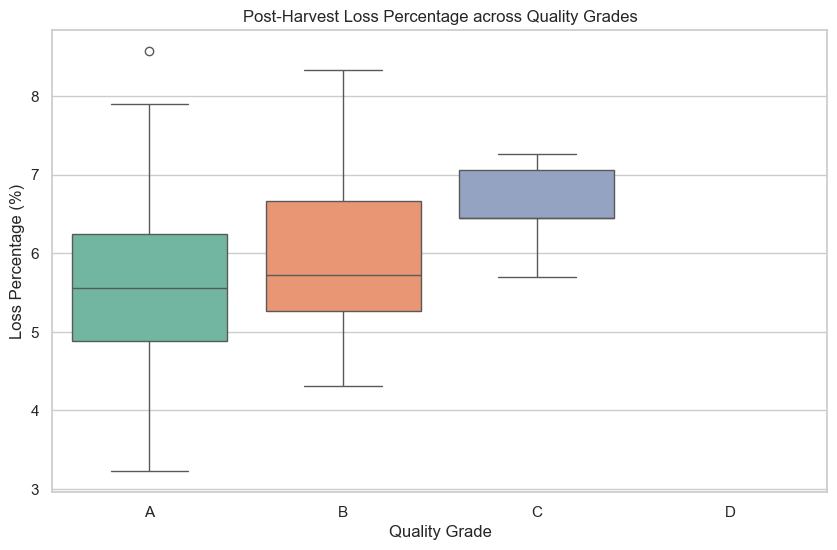

In [8]:
# Safely engineer row-level loss percentage for visualization
df["loss_pct"] = (
    df["quantity_lost_ton"] / df["quantity_harvested_ton"] * 100
).fillna(0.0)

# Boxplot for variance tracking
sns.boxplot(
    data=df,
    x="quality_grade",
    y="loss_pct",
    order=["A", "B", "C", "D"],
    palette="Set2",
)
plt.title("Post-Harvest Loss Percentage across Quality Grades")
plt.ylabel("Loss Percentage (%)")
plt.xlabel("Quality Grade")
plt.show()

## Financial Metrics Correlation

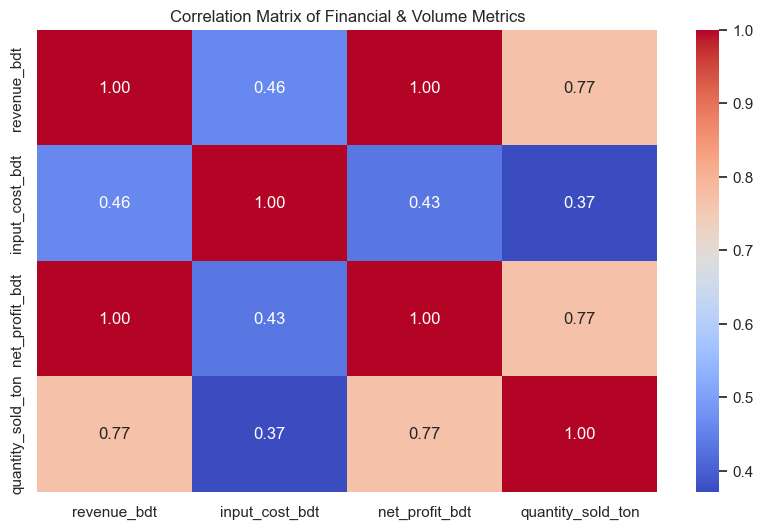

In [9]:
financial_cols = [
    "revenue_bdt",
    "input_cost_bdt",
    "net_profit_bdt",
    "quantity_sold_ton",
]

# Generate Heatmap
sns.heatmap(df[financial_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Financial & Volume Metrics")
plt.show()

## Top Yield and Profit Insights

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_32960\2417217595.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_crops.values, y=top_crops.index, palette="crest")


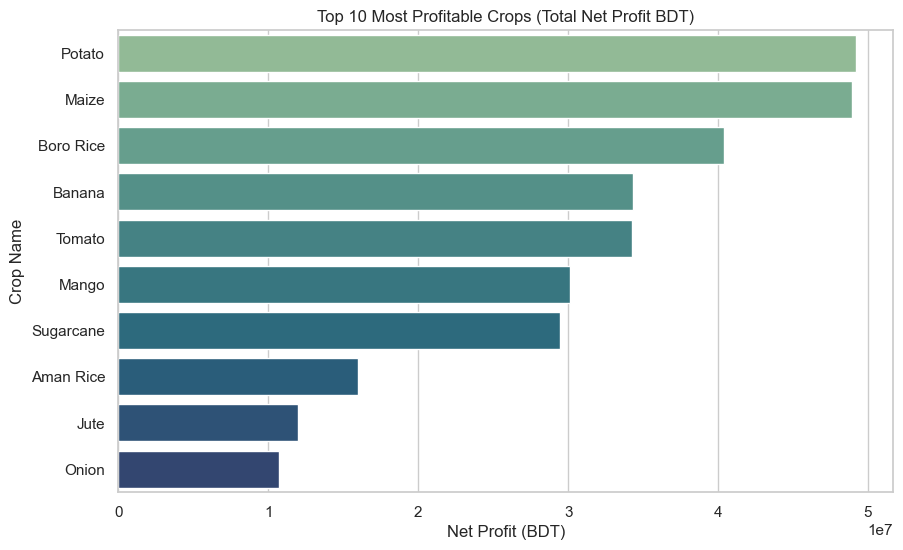

In [10]:
top_crops = (
    df.groupby("crop_name")["net_profit_bdt"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
sns.barplot(x=top_crops.values, y=top_crops.index, palette="crest")
plt.title("Top 10 Most Profitable Crops (Total Net Profit BDT)")
plt.xlabel("Net Profit (BDT)")
plt.ylabel("Crop Name")
plt.show()